# Safe feature-space visualization for MorphPT vs frozen encoders

This version is designed to avoid Jupyter kernel crashes.

Main changes from the earlier notebook:

- Loads only metadata columns plus `emb_2p5x`, not all embedding columns.
- Aligns files by row order by default, because your extracted files came from the same sampled parquet.
- Fits UMAP on a smaller balanced subset by default.
- Applies PCA to 50 dimensions before UMAP.
- Limits BLAS, OpenMP, and numba thread counts.
- Processes encoders one at a time and releases memory.

## 0. Thread limits

Run this cell first after restarting the kernel.

In [1]:
import os

# These must be set before importing numpy, sklearn, numba, or umap.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMBA_NUM_THREADS"] = "1"

## 1. Imports

In [ ]:
from pathlib import Path
import re
import gc
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize

try:
    import pyarrow.parquet as pq
except Exception:
    pq = None

try:
    import umap
except ImportError as e:
    raise ImportError("Install umap-learn first: pip install umap-learn") from e

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)

## 2. Paths and settings

In [ ]:
PROJECT_ROOT = Path("/hpc/group/jilab/tc459/MorphPT")
EMB_DIR = PROJECT_ROOT / "results/embeddings/core500"
OUT_DIR = PROJECT_ROOT / "results/figures/feature_space_core500_safe_200"
OUT_DIR.mkdir(parents=True, exist_ok=True)

FILES = {
    "MorphPT": EMB_DIR / "morphpt_router_core500_by_fine.parquet",
    "Frozen DINOv3": EMB_DIR / "frozen_dinov3_core500_by_fine.parquet",
    "Frozen SimCLR": EMB_DIR / "frozen_simclr_core500_by_fine.parquet",
}

EMB_COL = "emb_2p5x"

SEED = 1337

# Safer defaults. Increase to 250 or 500 only after the notebook works.
FIT_PER_CLASS = 250
PLOT_PER_CLASS = 200

# UMAP on PCA-reduced embeddings is much less likely to crash.
PCA_PRE_COMPONENTS = 50

UMAP_KWARGS = dict(
    n_neighbors=50,
    min_dist=0.30,
    metric="cosine",
    random_state=SEED,
    low_memory=True,
    n_jobs=1,
)

POINT_SIZE = 6
POINT_ALPHA = 0.70
DPI = 300

# Safer because both extracted files came from the same sampled parquet.
# Use "cell_id" only if you are sure cell_id is unique.
ALIGN_MODE = "row_order"

## 3. Load only needed columns

In [4]:
def available_columns(path):
    if pq is not None:
        return pq.ParquetFile(path).schema_arrow.names
    # Fallback if pyarrow schema access fails. This reads the file.
    return list(pd.read_parquet(path).columns)


def read_needed_parquet(path, encoder_name):
    cols = available_columns(path)

    candidates = [
        "cell_id",
        "fine_label",
        "label",
        "target_label",
        "coarse_label",
        "coarse_label_str",
        "tissue",
        EMB_COL,
    ]
    use_cols = [c for c in candidates if c in cols]

    if EMB_COL not in use_cols:
        raise RuntimeError(f"{encoder_name}: missing {EMB_COL}. Available columns: {cols}")

    df = pd.read_parquet(path, columns=use_cols)

    if "cell_id" not in df.columns:
        df["cell_id"] = np.arange(len(df)).astype(str)
        warnings.warn(f"{encoder_name}: missing cell_id, using row index as cell_id.")
    else:
        df["cell_id"] = df["cell_id"].astype(str)

    if "fine_label" in df.columns:
        df["fine_label_plot"] = df["fine_label"].astype(str)
    elif "label" in df.columns:
        df["fine_label_plot"] = df["label"].astype(str)
    elif "target_label" in df.columns:
        df["fine_label_plot"] = df["target_label"].astype(str)
    else:
        raise RuntimeError(f"{encoder_name}: no fine label column found. Columns: {list(df.columns)}")

    if "coarse_label_str" in df.columns:
        df["coarse_label_plot"] = df["coarse_label_str"].astype(str)
    elif "coarse_label" in df.columns:
        df["coarse_label_plot"] = df["coarse_label"].astype(str)
    else:
        df["coarse_label_plot"] = "unknown"
        warnings.warn(f"{encoder_name}: no coarse label column found.")

    return df


dfs = {}
for name, path in FILES.items():
    if path.exists():
        df = read_needed_parquet(path, name)
        dfs[name] = df
        print(f"{name:<14} {len(df):>7,} rows  cols={list(df.columns)}")
    else:
        print(f"{name:<14} missing, skipped: {path}")

if not dfs:
    raise RuntimeError("No embedding parquet files found.")

MorphPT         10,500 rows  cols=['cell_id', 'fine_label', 'label', 'coarse_label', 'tissue', 'emb_2p5x', 'fine_label_plot', 'coarse_label_plot']
Frozen DINOv3   10,500 rows  cols=['cell_id', 'label', 'target_label', 'coarse_label', 'tissue', 'emb_2p5x', 'fine_label_plot', 'coarse_label_plot']
Frozen SimCLR   10,500 rows  cols=['cell_id', 'label', 'target_label', 'coarse_label', 'tissue', 'emb_2p5x', 'fine_label_plot', 'coarse_label_plot']


## 4. Validate labels and choose a shared subset

This defaults to row-order alignment. That is safer here because both outputs were extracted from the same sampled parquet and should have identical row order.

In [5]:
names = list(dfs.keys())
ref_name = names[0]
ref = dfs[ref_name].copy()

if ALIGN_MODE == "row_order":
    n_ref = len(ref)
    for name, df in dfs.items():
        if len(df) != n_ref:
            raise RuntimeError(f"{name} has {len(df)} rows, but {ref_name} has {n_ref}. Use ALIGN_MODE='cell_id' instead.")
    print("Using row-order alignment.")
else:
    # Use cell_id alignment only if IDs are unique.
    for name, df in dfs.items():
        dup = df["cell_id"].duplicated().sum()
        if dup > 0:
            raise RuntimeError(f"{name} has {dup} duplicate cell_id values. Use row-order alignment.")
    common_ids = set(dfs[names[0]]["cell_id"])
    for name in names[1:]:
        common_ids &= set(dfs[name]["cell_id"])
    common_ids = sorted(common_ids)
    if not common_ids:
        raise RuntimeError("No common cell_id values across encoders.")
    for name in names:
        dfs[name] = dfs[name].set_index("cell_id").loc[common_ids].reset_index()
    ref = dfs[ref_name].copy()
    print("Using cell_id alignment. Common cells:", len(common_ids))

print("Reference:", ref_name)
print("Rows:", len(ref))
print("Fine classes:", ref["fine_label_plot"].nunique())
print(ref["fine_label_plot"].value_counts().sort_index().to_string())

# Check whether the labels agree by row order.
if ALIGN_MODE == "row_order":
    for name, df in dfs.items():
        same = (df["fine_label_plot"].to_numpy() == ref["fine_label_plot"].to_numpy()).mean()
        print(f"{name:<14} fine-label row agreement with {ref_name}: {same:.4f}")

Using row-order alignment.
Reference: MorphPT
Rows: 10500
Fine classes: 21
fine_label_plot
Astrocytes                   500
B cells                      500
Colon cancer cells           500
Endothelial cells            500
Epithelial cells             500
Fibroblasts                  500
Liver cancer cells           500
Lung cancer cells            500
Microglia                    500
Myeloid cells                500
NK cells                     500
Neurons                      500
Oligodendrocytes             500
Ovary cancer cells           500
Pancreas cancer cells        500
Pericytes                    500
Skin cancer cells            500
Smooth muscle cells          500
Stem and progenitor cells    500
Stromal cells                500
T cells                      500
MorphPT        fine-label row agreement with MorphPT: 1.0000
Frozen DINOv3  fine-label row agreement with MorphPT: 1.0000
Frozen SimCLR  fine-label row agreement with MorphPT: 1.0000


In [6]:
def balanced_row_indices(df, label_col, max_per_class, seed):
    parts = []
    for label, grp in df.groupby(label_col, sort=True):
        n = min(len(grp), max_per_class)
        parts.append(grp.sample(n=n, random_state=seed).index.to_numpy())
    idx = np.concatenate(parts)
    rng = np.random.default_rng(seed)
    rng.shuffle(idx)
    return idx


fit_idx = balanced_row_indices(ref, "fine_label_plot", FIT_PER_CLASS, SEED)

# Plot subset is a subset of fit subset.
fit_ref = ref.iloc[fit_idx].copy()
plot_idx_within_ref = balanced_row_indices(fit_ref.reset_index(drop=False), "fine_label_plot", PLOT_PER_CLASS, SEED)
plot_idx = fit_ref.iloc[plot_idx_within_ref].index.to_numpy()

print("Fit cells:", len(fit_idx))
print("Plot cells:", len(plot_idx))
print(ref.iloc[fit_idx]["fine_label_plot"].value_counts().sort_index().to_string())

Fit cells: 4200
Plot cells: 4200
fine_label_plot
Astrocytes                   200
B cells                      200
Colon cancer cells           200
Endothelial cells            200
Epithelial cells             200
Fibroblasts                  200
Liver cancer cells           200
Lung cancer cells            200
Microglia                    200
Myeloid cells                200
NK cells                     200
Neurons                      200
Oligodendrocytes             200
Ovary cancer cells           200
Pancreas cancer cells        200
Pericytes                    200
Skin cancer cells            200
Smooth muscle cells          200
Stem and progenitor cells    200
Stromal cells                200
T cells                      200


## 5. Utilities

In [ ]:
def safe_name(name):
    return re.sub(r"[^A-Za-z0-9]+", "_", name).strip("_").lower()


def stack_embedding_column(series):
    arrs = []
    for v in series:
        a = np.asarray(v, dtype=np.float32)
        if a.ndim != 1:
            raise ValueError(f"Expected 1D embedding, got {a.shape}")
        arrs.append(a)
    X = np.vstack(arrs).astype(np.float32)
    X = normalize(X, norm="l2", axis=1)
    return X


def pca_then_umap(X, name, force=False):
    cache = OUT_DIR / f"{safe_name(name)}_{EMB_COL}_umap_fit{FIT_PER_CLASS}_seed{SEED}.npz"
    if cache.exists() and not force:
        z = np.load(cache)
        return z["coords"]

    n_components = min(PCA_PRE_COMPONENTS, X.shape[0] - 1, X.shape[1])
    X_pca = PCA(n_components=n_components, random_state=SEED).fit_transform(X)
    X_pca = normalize(X_pca.astype(np.float32), norm="l2", axis=1)

    reducer = umap.UMAP(**UMAP_KWARGS)
    coords = reducer.fit_transform(X_pca)

    np.savez_compressed(cache, coords=coords)
    return coords


def pca_2d(X, name, force=False):
    cache = OUT_DIR / f"{safe_name(name)}_{EMB_COL}_pca2_fit{FIT_PER_CLASS}_seed{SEED}.npz"
    if cache.exists() and not force:
        z = np.load(cache)
        return z["coords"]

    coords = PCA(n_components=2, random_state=SEED).fit_transform(X)
    np.savez_compressed(cache, coords=coords)
    return coords


def make_color_map(labels, cmap_name="tab20"):
    labels = sorted(pd.unique(pd.Series(labels).astype(str)))
    cmap = plt.get_cmap(cmap_name, max(len(labels), 1))
    return {lab: cmap(i) for i, lab in enumerate(labels)}


def scatter_panel(ax, coords, labels, color_map, title):
    colors = [color_map[str(x)] for x in labels]
    ax.scatter(
        coords[:, 0],
        coords[:, 1],
        c=colors,
        s=POINT_SIZE,
        alpha=POINT_ALPHA,
        linewidths=0,
        rasterized=True,
    )
    ax.set_title(title, fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal", adjustable="box")
    for spine in ax.spines.values():
        spine.set_visible(False)


def save_legend(color_map, out_path, title=None):
    handles = [
        Line2D([0], [0], marker="o", linestyle="", label=lab,
               markerfacecolor=color, markeredgecolor="none", markersize=6)
        for lab, color in color_map.items()
    ]
    height = max(2.5, 0.22 * len(handles))
    fig = plt.figure(figsize=(4.8, height))
    ax = fig.add_subplot(111)
    ax.axis("off")
    ax.legend(handles=handles, loc="center left", frameon=False, title=title)
    fig.savefig(out_path, dpi=DPI, bbox_inches="tight")
    fig.savefig(out_path.with_suffix(".pdf"), bbox_inches="tight")
    plt.close(fig)

## 6. Compute coordinates one encoder at a time

In [ ]:
results = {}

for name, df in dfs.items():
    print(f"Processing {name}")

    X_fit = stack_embedding_column(df.iloc[fit_idx][EMB_COL])
    umap_fit = pca_then_umap(X_fit, name)
    pca_fit = pca_2d(X_fit, name)

    # Map original row index to position in fit array.
    pos = {int(row_i): j for j, row_i in enumerate(fit_idx)}
    plot_pos = np.array([pos[int(i)] for i in plot_idx], dtype=int)

    plot_df = df.iloc[plot_idx].copy()

    results[name] = {
        "umap": umap_fit[plot_pos],
        "pca": pca_fit[plot_pos],
        "fine": plot_df["fine_label_plot"].astype(str).to_numpy(),
        "coarse": plot_df["coarse_label_plot"].astype(str).to_numpy(),
        "cell_id": plot_df["cell_id"].astype(str).to_numpy(),
    }

    del X_fit, umap_fit, pca_fit, plot_df
    gc.collect()

print("Done.")

Processing MorphPT
Processing Frozen DINOv3
Processing Frozen SimCLR


## 7. UMAP by fine cell type

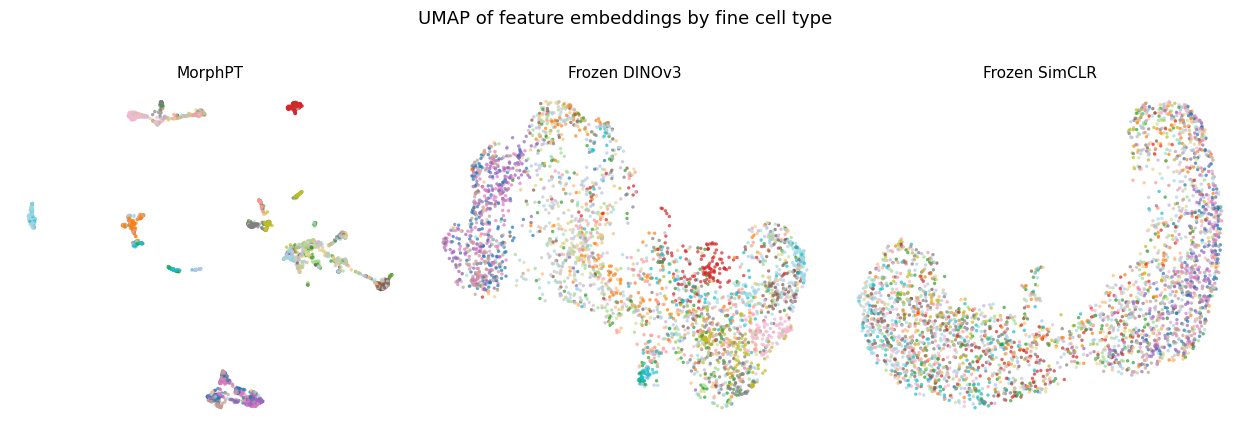

Saved: /hpc/group/jilab/tc459/MorphPT/results/figures/feature_space_core500_safe/umap_by_fine_cell_type.png


In [ ]:
all_fine = np.concatenate([r["fine"] for r in results.values()])
fine_colors = make_color_map(all_fine, cmap_name="tab20")


n = len(results)
fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 4.2), squeeze=False)
axes = axes[0]

for ax, (name, r) in zip(axes, results.items()):
    scatter_panel(ax, r["umap"], r["fine"], fine_colors, name)

fine_handles = [
    Line2D([0], [0], marker="o", linestyle="", label=lab,
           markerfacecolor=color, markeredgecolor="none", markersize=6)
    for lab, color in fine_colors.items()
 ]
fig.legend(
    handles=fine_handles,
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    frameon=False,
    title="Fine cell type",
 )

fig.suptitle("UMAP of feature embeddings by fine cell type", y=1.02, fontsize=13)
fig.tight_layout(rect=(0, 0, 0.86, 1))
out = OUT_DIR / "umap_by_fine_cell_type"
fig.savefig(out.with_suffix(".png"), dpi=DPI, bbox_inches="tight")
fig.savefig(out.with_suffix(".pdf"), bbox_inches="tight")
plt.show()

save_legend(fine_colors, OUT_DIR / "legend_fine_cell_type.png", title="Fine cell type")
print("Saved:", out.with_suffix(".png"))

## 8. UMAP by coarse group

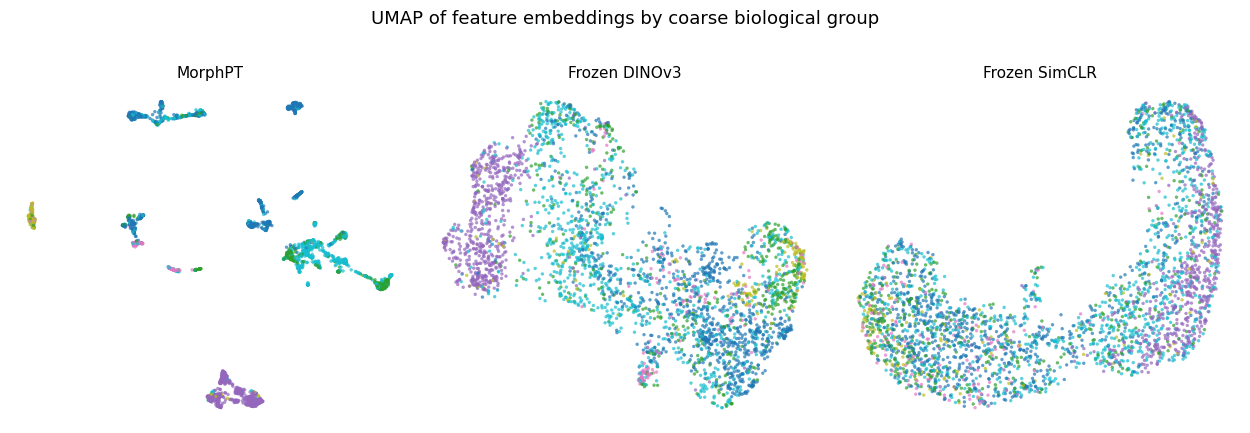

Saved: /hpc/group/jilab/tc459/MorphPT/results/figures/feature_space_core500_safe/umap_by_coarse_group.png


In [ ]:
all_coarse = np.concatenate([r["coarse"] for r in results.values()])
coarse_colors = make_color_map(all_coarse, cmap_name="tab10")

n = len(results)
fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 4.2), squeeze=False)
axes = axes[0]

for ax, (name, r) in zip(axes, results.items()):
    scatter_panel(ax, r["umap"], r["coarse"], coarse_colors, name)

coarse_handles = [
    Line2D([0], [0], marker="o", linestyle="", label=lab,
           markerfacecolor=color, markeredgecolor="none", markersize=6)
    for lab, color in coarse_colors.items()
 ]
fig.legend(
    handles=coarse_handles,
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    frameon=False,
    title="Coarse group",
 )

fig.suptitle("UMAP of feature embeddings by coarse biological group", y=1.02, fontsize=13)
fig.tight_layout(rect=(0, 0, 0.86, 1))
out = OUT_DIR / "umap_by_coarse_group"
fig.savefig(out.with_suffix(".png"), dpi=DPI, bbox_inches="tight")
fig.savefig(out.with_suffix(".pdf"), bbox_inches="tight")
plt.show()

save_legend(coarse_colors, OUT_DIR / "legend_coarse_group.png", title="Coarse group")
print("Saved:", out.with_suffix(".png"))

## 9. Combined UMAP panel

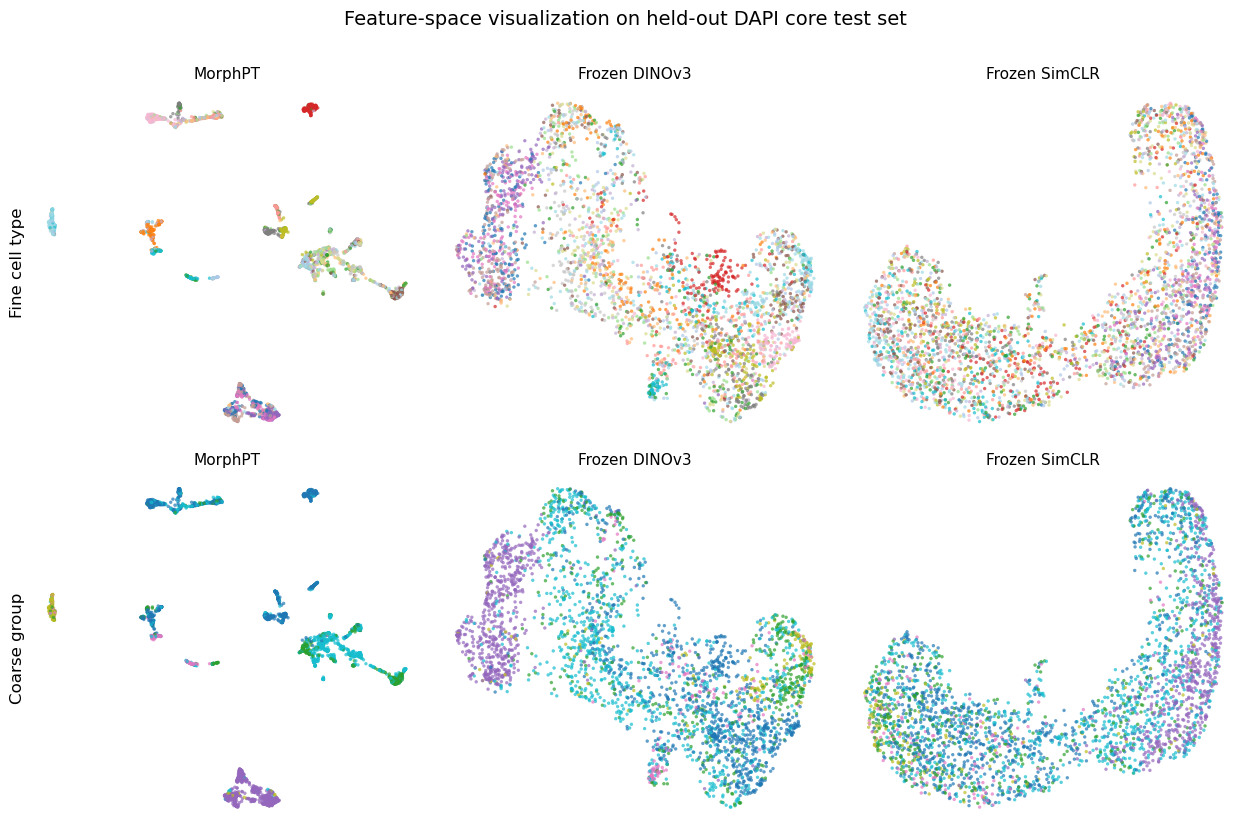

Saved: /hpc/group/jilab/tc459/MorphPT/results/figures/feature_space_core500_safe/umap_combined_fine_and_coarse.png


In [11]:
n = len(results)
fig, axes = plt.subplots(2, n, figsize=(4.2 * n, 8.2), squeeze=False)

for j, (name, r) in enumerate(results.items()):
    scatter_panel(axes[0, j], r["umap"], r["fine"], fine_colors, name)
    scatter_panel(axes[1, j], r["umap"], r["coarse"], coarse_colors, name)

axes[0, 0].set_ylabel("Fine cell type", fontsize=12)
axes[1, 0].set_ylabel("Coarse group", fontsize=12)

fig.suptitle("Feature-space visualization on held-out DAPI core test set", y=1.01, fontsize=14)
fig.tight_layout()
out = OUT_DIR / "umap_combined_fine_and_coarse"
fig.savefig(out.with_suffix(".png"), dpi=DPI, bbox_inches="tight")
fig.savefig(out.with_suffix(".pdf"), bbox_inches="tight")
plt.show()

print("Saved:", out.with_suffix(".png"))

## 10. PCA sanity check

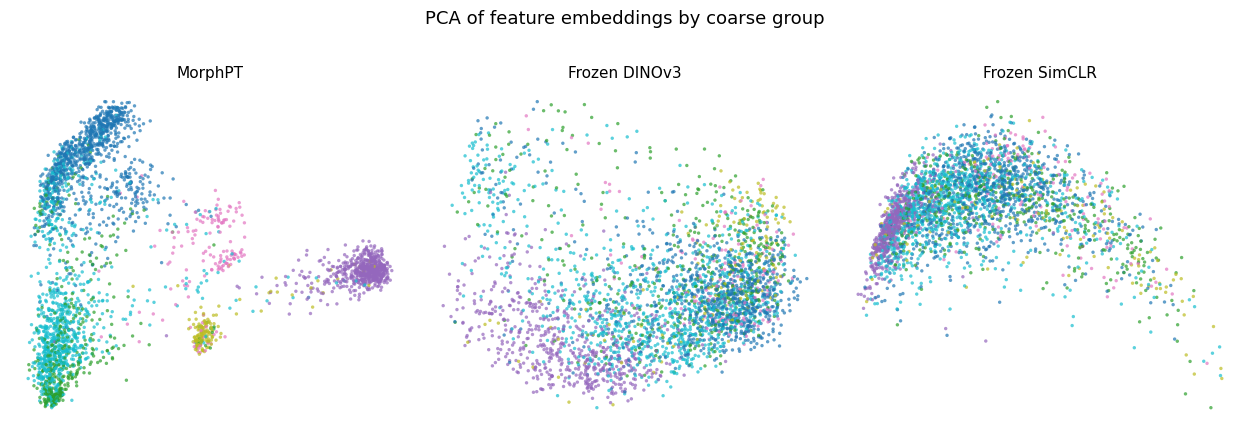

Saved: /hpc/group/jilab/tc459/MorphPT/results/figures/feature_space_core500_safe/pca_by_coarse_group.png


In [12]:
n = len(results)
fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 4.2), squeeze=False)
axes = axes[0]

for ax, (name, r) in zip(axes, results.items()):
    scatter_panel(ax, r["pca"], r["coarse"], coarse_colors, name)

fig.suptitle("PCA of feature embeddings by coarse group", y=1.02, fontsize=13)
fig.tight_layout()
out = OUT_DIR / "pca_by_coarse_group"
fig.savefig(out.with_suffix(".png"), dpi=DPI, bbox_inches="tight")
fig.savefig(out.with_suffix(".pdf"), bbox_inches="tight")
plt.show()

print("Saved:", out.with_suffix(".png"))

## 11. Save coordinates

In [13]:
coord_rows = []
for name, r in results.items():
    tmp = pd.DataFrame({
        "encoder": name,
        "cell_id": r["cell_id"],
        "fine_label": r["fine"],
        "coarse_label": r["coarse"],
        "umap_1": r["umap"][:, 0],
        "umap_2": r["umap"][:, 1],
        "pca_1": r["pca"][:, 0],
        "pca_2": r["pca"][:, 1],
    })
    coord_rows.append(tmp)

coords_df = pd.concat(coord_rows, ignore_index=True)
coords_path = OUT_DIR / "feature_space_coords_plot_subset.parquet"
coords_df.to_parquet(coords_path, index=False)
print("Saved:", coords_path)
coords_df.head()

Saved: /hpc/group/jilab/tc459/MorphPT/results/figures/feature_space_core500_safe/feature_space_coords_plot_subset.parquet


,encoder,cell_id,fine_label,coarse_label,umap_1,umap_2,pca_1,pca_2
0,MorphPT,Xenium_V1_hLymphNode_nondiseased_n315478,T cells,Lymphoid,20.454235,2.137486,-0.336694,-0.554095
1,MorphPT,Xenium_V1_hSkin_Melanoma_Base_n21214,T cells,Lymphoid,14.388291,11.712554,-0.140154,0.260515
2,MorphPT,Xenium_V1_hColon_Cancer_Base_n247684,B cells,Lymphoid,0.986565,8.407086,-0.101456,0.130966
3,MorphPT,Xenium_human_Lymph_Node_FFPE_n422176,Stromal cells,Stromal,-6.032854,8.381149,0.197064,-0.319317
4,MorphPT,Xenium_V1_FFPE_Human_Brain_Healthy_n1535,Oligodendrocytes,Neuroglial,7.762866,-9.061625,0.627462,-0.107110


## Suggested caption

Feature-space visualization on the held-out DAPI core test set. Encoders were frozen during feature extraction. MorphPT embeddings use the fused multi-view representation before the classifier head. Frozen DINOv3 uses the averaged normalized 2.5x and 10x view embeddings from the pretrained backbone. UMAP was fit separately for each encoder using the same balanced subset and identical parameters after PCA pre-reduction. Points are colored by fine cell type or coarse biological group.